<a href="https://colab.research.google.com/github/sushant758/ML-Exercises/blob/main/CAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [897]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')

In [898]:
df = pd.read_csv('train.csv')

In [899]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [900]:
df.shape

(188533, 13)

In [901]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [902]:
# 1. Shape
print("Shape:", df.shape)

Shape: (188533, 13)


In [903]:
# 2. See ALL values including NaN for every column
print("\nNull counts:\n", df.isnull().sum())


Null counts:
 id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64


In [904]:
# 3. Percentage of nulls
print("\nNull %:\n", df.isnull().sum() / len(df) * 100)



Null %:
 id               0.000000
brand            0.000000
model            0.000000
model_year       0.000000
milage           0.000000
fuel_type        2.696080
engine           0.000000
transmission     0.000000
ext_col          0.000000
int_col          0.000000
accident         1.300568
clean_title     11.360876
price            0.000000
dtype: float64


In [905]:
# 3. Percentage of nulls
print("\nNull %:\n", df.isnull().sum() / len(df) * 100)


Null %:
 id               0.000000
brand            0.000000
model            0.000000
model_year       0.000000
milage           0.000000
fuel_type        2.696080
engine           0.000000
transmission     0.000000
ext_col          0.000000
int_col          0.000000
accident         1.300568
clean_title     11.360876
price            0.000000
dtype: float64


In [906]:
# 4. Data types
print("\nDtypes:\n", df.dtypes)


Dtypes:
 id               int64
brand           object
model           object
model_year       int64
milage           int64
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price            int64
dtype: object


# fill null values

In [907]:
df['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,165940
Hybrid,6832
E85 Flex Fuel,5406
Diesel,3955
–,781
Plug-In Hybrid,521
not supported,15


In [908]:
# before doing anything i have to remove '-' and not supported
df['fuel_type'] = df['fuel_type'].replace(['–' , 'not supported'], np.nan)

In [909]:
df['fuel_type'].isnull().sum()

np.int64(5879)

In [910]:
df['fuel_type'].fillna(df['fuel_type'].mode()[0] , inplace=True)

In [911]:
df['fuel_type'].isnull().sum()

np.int64(0)

In [912]:
df['fuel_type'].unique()

array(['Gasoline', 'E85 Flex Fuel', 'Hybrid', 'Diesel', 'Plug-In Hybrid'],
      dtype=object)

In [913]:
df = pd.get_dummies(df, columns=['fuel_type'], drop_first=True, dtype=int)

In [914]:
df.head()

,id,brand,model,model_year,milage,engine,transmission,ext_col,int_col,accident,clean_title,price,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
0,0,MINI,Cooper S Base,2007,213000,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200,0,1,0,0
1,1,Lincoln,LS V8,2002,143250,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999,0,1,0,0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900,1,0,0,0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000,0,1,0,0
4,4,Mercedes-Benz,Metris Base,2021,7388,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500,0,1,0,0


In [915]:
# accident

In [916]:
df['accident'].value_counts(dropna=False)

,count
accident,
None reported,144514
At least 1 accident or damage reported,41567
NaN,2452


In [917]:
# since accident is an import feature so i will not remove it , instead i will create another column unknown
df['accident'] = df['accident'].fillna('Unknown')

In [918]:
df['accident'].isnull().sum()

np.int64(0)

In [919]:
df['accident'].value_counts(dropna=False)

,count
accident,
None reported,144514
At least 1 accident or damage reported,41567
Unknown,2452


In [920]:
df['accident'] = df['accident'].replace('Unknown',df['accident'].mode()[0])

In [921]:
df['accident'] = df['accident'].map({'None reported': 0,'At least 1 accident or damage reported': 1})

In [922]:
df['accident'] = df['accident'].astype('Int64')

In [923]:
df['accident'].isnull().sum()

np.int64(0)

In [924]:
# here all 2452 "Unknown" values became NaN. its not null values

In [925]:
# verify this
df['accident'].value_counts(dropna=False)

,count
accident,
0,146966
1,41567


In [926]:
df.head()

,id,brand,model,model_year,milage,engine,transmission,ext_col,int_col,accident,clean_title,price,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
0,0,MINI,Cooper S Base,2007,213000,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,0,Yes,4200,0,1,0,0
1,1,Lincoln,LS V8,2002,143250,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,1,Yes,4999,0,1,0,0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,0,Yes,13900,1,0,0,0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,0,Yes,45000,0,1,0,0
4,4,Mercedes-Benz,Metris Base,2021,7388,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,0,Yes,97500,0,1,0,0


In [927]:
df.isnull().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [928]:
# clean_title

In [929]:
df['clean_title'].value_counts(dropna = False)

,count
clean_title,
Yes,167114
NaN,21419


In [930]:
df['clean_title'].isnull().sum()

np.int64(21419)

In [931]:
df['clean_title'] = df['clean_title'].fillna('Unknown')

In [932]:
df['clean_title'] = df['clean_title'].map({'Yes': 1, 'Unknown': 0})

In [933]:
df['clean_title'].isnull().sum()

np.int64(0)

In [934]:
df.head()

,id,brand,model,model_year,milage,engine,transmission,ext_col,int_col,accident,clean_title,price,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
0,0,MINI,Cooper S Base,2007,213000,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,0,1,4200,0,1,0,0
1,1,Lincoln,LS V8,2002,143250,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,1,1,4999,0,1,0,0
2,2,Chevrolet,Silverado 2500 LT,2002,136731,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,0,1,13900,1,0,0,0
3,3,Genesis,G90 5.0 Ultimate,2017,19500,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,0,1,45000,0,1,0,0
4,4,Mercedes-Benz,Metris Base,2021,7388,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,0,1,97500,0,1,0,0


In [935]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   id                        188533 non-null  int64 
 1   brand                     188533 non-null  object
 2   model                     188533 non-null  object
 3   model_year                188533 non-null  int64 
 4   milage                    188533 non-null  int64 
 5   engine                    188533 non-null  object
 6   transmission              188533 non-null  object
 7   ext_col                   188533 non-null  object
 8   int_col                   188533 non-null  object
 9   accident                  188533 non-null  Int64 
 10  clean_title               188533 non-null  int64 
 11  price                     188533 non-null  int64 
 12  fuel_type_E85 Flex Fuel   188533 non-null  int64 
 13  fuel_type_Gasoline        188533 non-null  int64 
 14  fuel

In [936]:
df.isna().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


# Outliers

In [937]:
# first lets remove the id
df.drop('id',axis=1 , inplace = True )

In [938]:
df.head()

,brand,model,model_year,milage,engine,transmission,ext_col,int_col,accident,clean_title,price,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid
0,MINI,Cooper S Base,2007,213000,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,0,1,4200,0,1,0,0
1,Lincoln,LS V8,2002,143250,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,1,1,4999,0,1,0,0
2,Chevrolet,Silverado 2500 LT,2002,136731,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,0,1,13900,1,0,0,0
3,Genesis,G90 5.0 Ultimate,2017,19500,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,0,1,45000,0,1,0,0
4,Mercedes-Benz,Metris Base,2021,7388,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,0,1,97500,0,1,0,0


<Axes: xlabel='brand'>

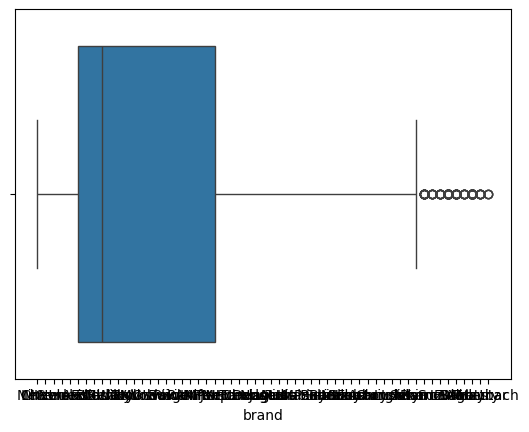

In [939]:
# check outlier for brand
sns.boxplot(x=df['brand'])

In [940]:
df['brand'].describe()

,brand
count,188533
unique,57
top,Ford
freq,23088


In [941]:
counts = df['brand'].value_counts()
rare_brands = counts[counts < 50].index
df['brand'] = df['brand'].replace(rare_brands, 'Other')

<Axes: xlabel='model'>

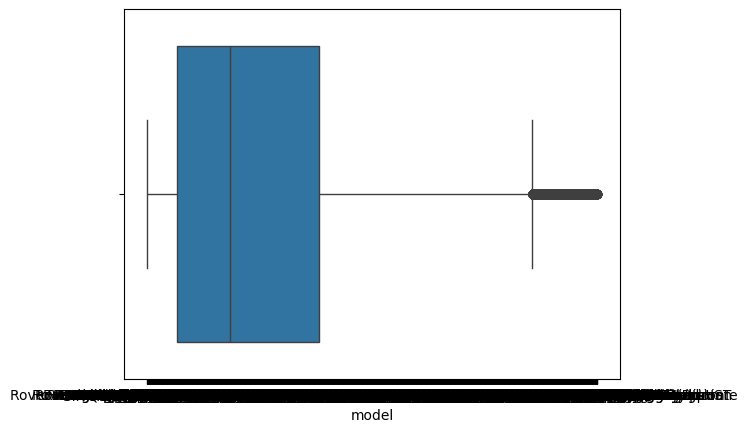

In [942]:
# check outlier for model
sns.boxplot(x=df['model'])

In [943]:
df['model'].unique()

array(['Cooper S Base', 'LS V8', 'Silverado 2500 LT', ..., 'e-Golf SE',
       'Integra w/A-Spec Tech Package', 'IONIQ Plug-In Hybrid SEL'],
      dtype=object)

In [944]:
print(df['model'].nunique())

1897


In [945]:
df['model'].value_counts()

,count
model,
F-150 XLT,2945
M3 Base,2229
Camaro 2SS,1709
M4 Base,1622
Mustang GT Premium,1526
...,...
ForTwo Pure,2
XLR Base,1
X5 3.0i,1


In [946]:
counts = df['model'].value_counts()
rare_models = counts[counts < 100].index
df['model'] = df['model'].replace(rare_models, 'Other')

<Axes: xlabel='model_year'>

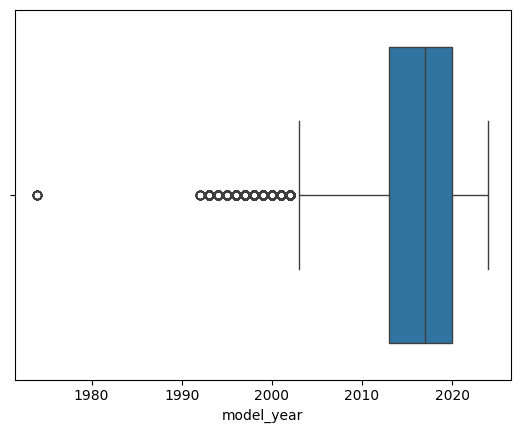

In [947]:
# model_year
sns.boxplot(x=df['model_year'])

In [948]:
print(df['model_year'].min())
print(df['model_year'].max())

1974
2024


In [949]:
df = df[df['model_year'] != 1974]

In [950]:
from datetime import datetime

In [951]:
df['car_age'] = datetime.now().year - df['model_year']

In [952]:
df.head()

,brand,model,model_year,milage,engine,transmission,ext_col,int_col,accident,clean_title,price,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,car_age
0,MINI,Cooper S Base,2007,213000,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,0,1,4200,0,1,0,0,19
1,Lincoln,Other,2002,143250,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,1,1,4999,0,1,0,0,24
2,Chevrolet,Other,2002,136731,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,0,1,13900,1,0,0,0,24
3,Genesis,Other,2017,19500,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,0,1,45000,0,1,0,0,9
4,Mercedes-Benz,Metris Base,2021,7388,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,0,1,97500,0,1,0,0,5


<Axes: xlabel='milage'>

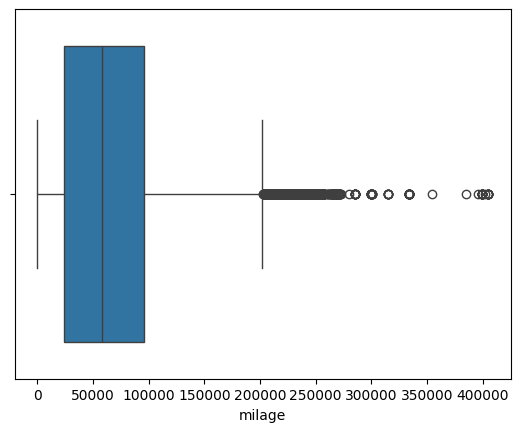

In [953]:
# milage
sns.boxplot(x=df['milage'])

In [954]:
df['milage'].describe()

,milage
count,188521.000000
mean,65705.171084
std,49797.964242
min,100.000000
25%,24115.000000
50%,57785.000000
75%,95400.000000
max,405000.000000


In [955]:
# checking outliers with the help of IQR
Q1 = df['milage'].quantile(0.25)
Q3 = df['milage'].quantile(0.75)

In [956]:
IQR = Q3 - Q1

In [957]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [958]:
print(lower_limit)
print(upper_limit)

-82812.5
202327.5


In [959]:
min_val = df['milage'].min()
max_val = df['milage'].max()

if min_val < lower_limit and max_val > upper_limit:
    print("Both lower and upper outliers exist")

elif min_val < lower_limit:
    print("Lower outliers exist")

elif max_val > upper_limit:
    print("Upper outliers exist")

else:
    print("No outliers detected")

Upper outliers exist


In [960]:
# NOw check by skewness
df['milage'].skew()

np.float64(0.8950706226255637)

In [961]:
df['milage'] = np.sqrt(df['milage'])

In [962]:
df['milage'].skew()

np.float64(0.0110204703909408)

<Axes: xlabel='milage'>

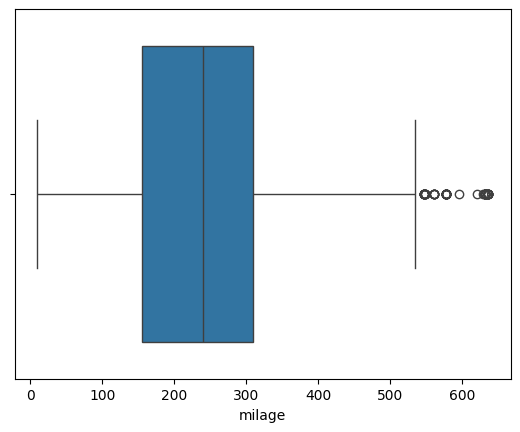

In [963]:
sns.boxplot(x=df['milage'])

In [964]:
# fuel_type
# no need to check outliers for this feature bcz , i have removed null values of this and created dummies of this features

<Axes: xlabel='engine'>

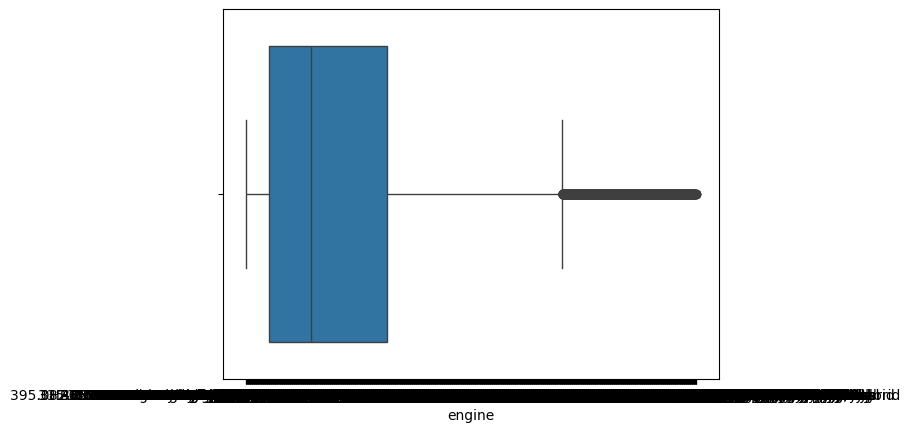

In [967]:
# engine
sns.boxplot(x=df['engine'])

In [974]:
# first i will check null values in it
df['engine'].isnull().sum()

np.int64(0)

In [977]:
# first i will extract HP , No of litres, no of cylinder from the engine section and create their dummies . fuel is already defined .
# and drop the engine section


df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)

df['engine_liters'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)

df['cylinders'] = df['engine'].str.extract(r'(\d+)\sCylinder').astype(float)



df.drop('engine' , axis = 1 , inplace = True)

In [978]:
# and for now no need to check null and outliers

In [979]:
df.head()

,brand,model,model_year,milage,transmission,ext_col,int_col,accident,clean_title,price,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,car_age,horsepower,engine_liters,cylinders
0,MINI,Cooper S Base,2007,461.519230,A/T,Yellow,Gray,0,1,4200,0,1,0,0,19,172.0,1.6,4.0
1,Lincoln,Other,2002,378.483817,A/T,Silver,Beige,1,1,4999,0,1,0,0,24,252.0,3.9,8.0
2,Chevrolet,Other,2002,369.771551,A/T,Blue,Gray,0,1,13900,1,0,0,0,24,320.0,5.3,8.0
3,Genesis,Other,2017,139.642400,Transmission w/Dual Shift Mode,Black,Black,0,1,45000,0,1,0,0,9,420.0,5.0,8.0
4,Mercedes-Benz,Metris Base,2021,85.953476,7-Speed A/T,Black,Beige,0,1,97500,0,1,0,0,5,208.0,2.0,4.0


<Axes: xlabel='transmission'>

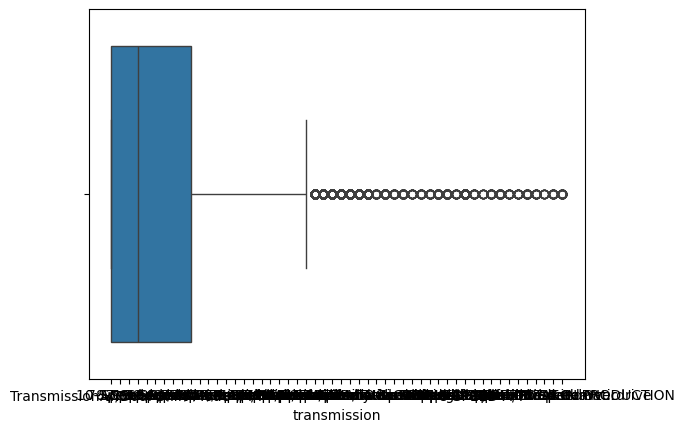

In [981]:
# transmission
sns.boxplot(x=df['transmission'])

In [983]:
df['transmission'].value_counts(dropna = False)

,count
transmission,
A/T,49900
8-Speed A/T,20645
Transmission w/Dual Shift Mode,19255
6-Speed A/T,18044
6-Speed M/T,11997
7-Speed A/T,11124
Automatic,10690
8-Speed Automatic,8431
10-Speed A/T,8044


In [984]:
# '–', '2', 'F', 'SCHEDULED FOR OR IN PRODUCTION' these are not of use so i will replace them .
unknown_transmission = ['–', '2', 'F', 'SCHEDULED FOR OR IN PRODUCTION']

df['transmission'] = df['transmission'].replace(unknown_transmission, np.nan)

In [986]:
print(df['transmission'].isnull().sum())

245


In [987]:
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

In [990]:
print(df['transmission'].isnull().sum())

0


In [991]:
df['transmission'].value_counts()

,count
transmission,
A/T,50145
8-Speed A/T,20645
Transmission w/Dual Shift Mode,19255
6-Speed A/T,18044
6-Speed M/T,11997
7-Speed A/T,11124
Automatic,10690
8-Speed Automatic,8431
10-Speed A/T,8044


In [993]:
freq = df['transmission'].value_counts()

rare_categories = freq[freq < 50].index

df['transmission'] = df['transmission'].replace(rare_categories,'Rare')

In [994]:
df['transmission'].value_counts()

,count
transmission,
A/T,50145
8-Speed A/T,20645
Transmission w/Dual Shift Mode,19255
6-Speed A/T,18044
6-Speed M/T,11997
7-Speed A/T,11124
Automatic,10690
8-Speed Automatic,8431
10-Speed A/T,8044
